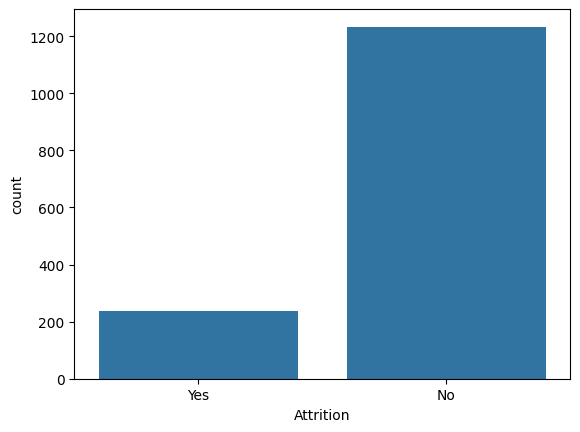

In [27]:
import seaborn as sns 
import pandas as pd 
import matplotlib.pyplot as plt
df = pd.read_excel("dataset.xlsx")
#
sns.countplot(x='Attrition', data=df)
plt.show()

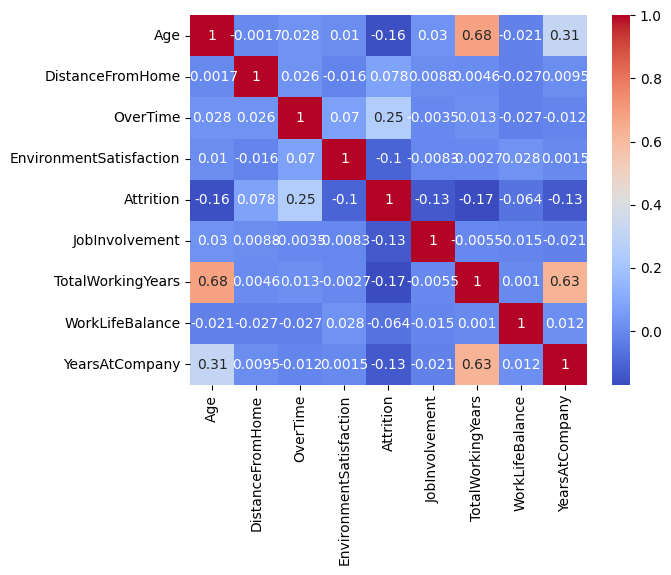

In [28]:
from data_processing import df_pro
selected_features = [
    "Age",
    "DistanceFromHome",
    "OverTime",
    "EnvironmentSatisfaction",
    "Attrition",
    "JobInvolvement", 
    "TotalWorkingYears",
    "WorkLifeBalance",
    "YearsAtCompany"
]
subset = df_pro[selected_features]
subset_corr = subset.corr()
sns.heatmap(
    subset_corr,
    annot=True,
    cmap='coolwarm')
plt.show()

Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127


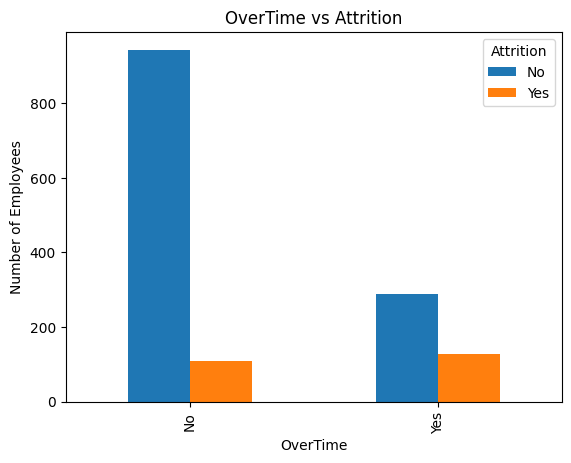

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

#groupby() calculate every possibiity of overtime and attrition combinition(group).
#e.g. [Yes, No][Yes, Yes][No, No][No, Yes]
#size() : size calculate number of rows lies in each group.
#unstack() : Convert all result into table.
data = df.groupby(["OverTime", "Attrition"]).size().unstack()
print(data)
# Draw bar graph on table data
data.plot(kind="bar")

plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.title("OverTime vs Attrition")

plt.show()

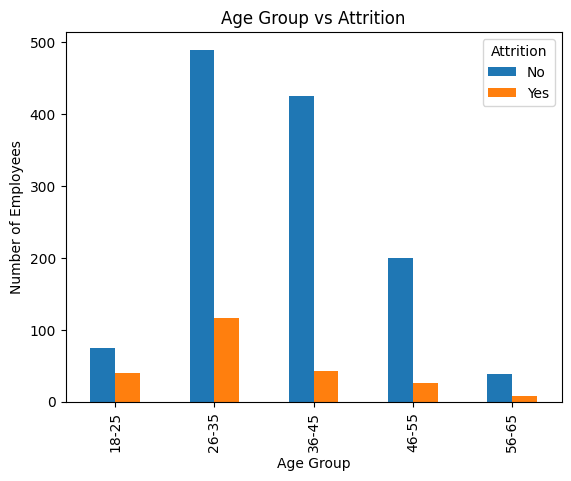

In [30]:
#cut() function divides age column into ranges, and cut function have parameters (e.g. age column, bins list, labels list)
#bin tells the range of each intervel and label is category.
#cut() function create new column in dataframe
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65"]
)

#groupby() calculate every possibiity of overtime and attrition combinition(group).
#e.g. [Yes, No][Yes, Yes][No, No][No, Yes]
#size() : size calculate number of rows lies in each group.
#unstack() : Convert all result into table.
data = df.groupby(["AgeGroup", "Attrition"]).size().unstack()

#plot a bar graph for data(dataframe).
#more types of kind of plot function ("line", "hist", "scatter", "pie")
data.plot(kind="bar")

plt.xlabel("Age Group")
plt.ylabel("Number of Employees")
plt.title("Age Group vs Attrition")

plt.show()

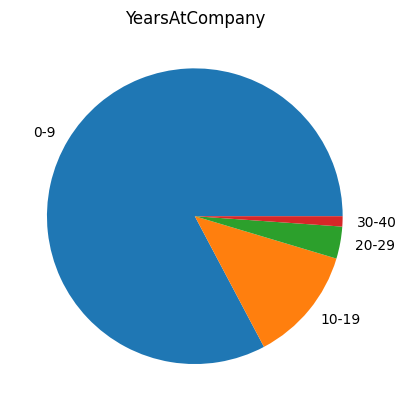

In [ ]:
#pie chart show the experence category of company employees 
df["years_at_company"] = pd.cut(df["YearsAtCompany"], bins = [0,10,20,30,40], labels =["0-9", "10-19", "20-29", "30-40"])
datatable = df["years_at_company"].value_counts()
datatable.plot(kind = "pie")
plt.title("YearsAtCompany")
plt.show()

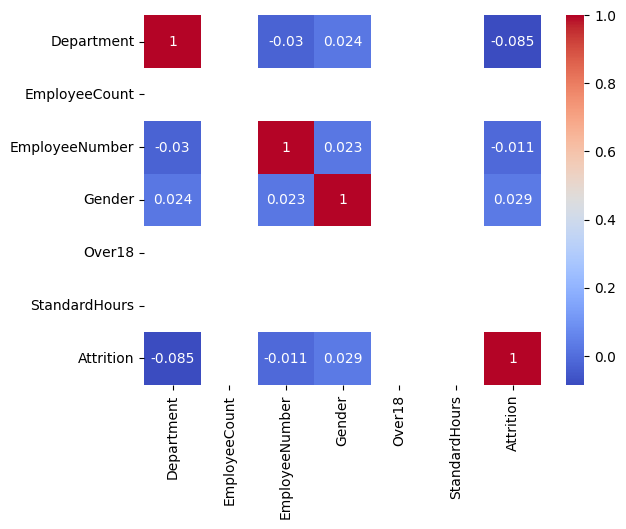

In [ ]:
#Show the relation between drop columns and Attrition by using heatmap.
selected_features_drop = [
    "Department","EducationField","EmployeeCount",
"EmployeeNumber","Gender","JobRole",
"Over18","StandardHours", "Attrition"
]
subset1 = df[selected_features_drop]
subset1["Over18"] = subset1["Over18"].map({"Y" : 1})
subset1["Department"] = subset1["Department"].map({"Sales":0, "Human Resources" : 1, "Research & Development" : 2})
subset1["Attrition"] = subset1["Attrition"].map({"Yes": 1, "No":0})
subset1["Gender"] = subset1["Gender"].map({"Male" : 1, "Female" : 0})
subset_corr = subset1.select_dtypes(include= "number").corr()
sns.heatmap(
    subset_corr,
    annot=True,
    cmap='coolwarm')
plt.show()